# Классификация бина рейтинга SoFIFA на следующий год после сезона

Матч → энкодер → агрегированный эмбеддинг → **головы классификации** (нейросеть, AdaBoost, XGBoost). Таргет — **бин по 5 пунктов** от 50 до 90 (8 классов). Данные матчей фильтруются как в `eda_data_with_dates.ipynb` (годы 2015–2016, команды с ≥30 матчами). На train применяется **oversampling / undersampling** по классам; метрика — **accuracy** на несбалансированном eval.

In [1]:
import sys
from pathlib import Path
import pickle
import subprocess

# Надёжно найти корень репозитория:
# 1) пробуем git rev-parse (лучший вариант)
# 2) иначе пробуем несколько типовых путей
# 3) иначе fallback: искать вверх от cwd

def _try_git_root() -> Path | None:
    try:
        out = subprocess.check_output(["git", "rev-parse", "--show-toplevel"], stderr=subprocess.DEVNULL)
        p = Path(out.decode().strip())
        return p if p.exists() else None
    except Exception:
        return None

candidates = []
git_root = _try_git_root()
if git_root is not None:
    candidates.append(git_root)

# локальный проект (если notebook запускают не из папки репо)
candidates += [
    Path("/Users/vasilij/Documents/ML/proj/ML_project-football-"),
]

# поиск вверх от cwd
try:
    p = Path.cwd()
except FileNotFoundError:
    p = Path("/")
while p != p.parent:
    candidates.append(p)
    p = p.parent

ROOT = None
for c in candidates:
    if (c / "models").exists():
        ROOT = c
        break

assert ROOT is not None, "Не удалось найти корень репозитория (папку с models/)"

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import torch
from torch.utils.data import DataLoader
from safetensors.torch import load_file as load_safetensors

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available()
    else "cpu"
)
print("ROOT:", ROOT)
print("Device:", device)

ROOT: /Users/vasilij/Documents/ML/proj/ML_project-football-
Device: mps


In [2]:
# Запускаем обучение/оценку голов для ВСЕХ моделей из mpp_mini_output/
# Тип энкодера определяем по имени папки: если есть "gmlp" -> gmlp, иначе transformer.

CKPT_ROOT = ROOT / "mpp_mini_output"
assert CKPT_ROOT.exists(), f"Не найдена папка: {CKPT_ROOT}"

def infer_model_type(ckpt_dir: Path) -> str:
    name = ckpt_dir.name.lower()
    return "gmlp" if "gmlp" in name else "transformer"

CKPT_DIRS = sorted(
    [d for d in CKPT_ROOT.iterdir() if d.is_dir() and (d / "model.safetensors").exists()],
    key=lambda p: p.name,
)
assert len(CKPT_DIRS) > 0, f"В {CKPT_ROOT} не найдено ни одного чекпоинта с model.safetensors"

METADATA_DIR = ROOT / "notebooks" / "train_sample_processed" / "metadata"
PROCESSED_CSV = ROOT / "notebooks" / "train_sample_processed" / "processed.csv"
RATINGS_BY_SEASON_CSV = ROOT / "dataset" / "sofifa_ratings_by_season.csv"
OUTPUT_BASE_DIR = ROOT / "notebooks" / "rating_head_output" / "next_year"
OUTPUT_BASE_DIR.mkdir(parents=True, exist_ok=True)

assert METADATA_DIR.exists(), f"Метаданные не найдены: {METADATA_DIR}"
assert PROCESSED_CSV.exists(), f"CSV не найден: {PROCESSED_CSV}"
assert RATINGS_BY_SEASON_CSV.exists(), f"Рейтинги по сезонам не найдены: {RATINGS_BY_SEASON_CSV}"

print("CKPT_ROOT:", CKPT_ROOT)
print("Found checkpoints:")
for d in CKPT_DIRS:
    print("-", d.name, "| type:", infer_model_type(d))

CKPT_ROOT: /Users/vasilij/Documents/ML/proj/ML_project-football-/mpp_mini_output
Found checkpoints:
- RisingBaller_128_learned | type: transformer
- RisingBaller_128_sinusoidal | type: transformer
- RisingBaller_64_learned | type: transformer
- RisingBaller_64_sinusoidal | type: transformer
- gMLP_main_eq_128_te_f | type: gmlp
- gMLP_main_eq_64_te_f | type: gmlp


In [3]:
def load_vocab(metadata_dir: Path):
    with open(metadata_dir / "player_name2id.pickle", "rb") as f:
        player_name2id = pickle.load(f)
    with open(metadata_dir / "team_name2id.pickle", "rb") as f:
        team_name2id = pickle.load(f)
    n = len(player_name2id)
    return {
        "player_name2id": player_name2id,
        "team_name2id": team_name2id,
        "player_pad_token_id": n + 1,
        "team_pad_token_id": len(team_name2id),
    }

vocab = load_vocab(METADATA_DIR)
player_pad_token_id = vocab["player_pad_token_id"]
teams_vocab_size = vocab["team_pad_token_id"] + 1
print("player_pad_token_id:", player_pad_token_id)

player_pad_token_id: 6394


In [4]:
import pandas as pd
from data.sofifa import build_aggregated_embeddings_next_year, SofifaAggregatedDataset
from data.preprocessing import FORM_STATS_SIZE

# Фильтр матчей (как в eda_data_with_dates) — задаём здесь, чтобы ячейка работала без предыдущего конфига
DATA_WITH_DATES = ROOT / "dataset" / "data_with_dates.csv"
YEARS_FILTER = [2015, 2016]
MIN_TEAM_MATCHES_FILTER = 30
PROCESSED_CSV = ROOT / "notebooks" / "train_sample_processed" / "processed.csv"
RATINGS_BY_SEASON_CSV = ROOT / "dataset" / "sofifa_ratings_by_season.csv"
assert DATA_WITH_DATES.exists(), f"Не найден {DATA_WITH_DATES}"
assert PROCESSED_CSV.exists(), f"Не найден {PROCESSED_CSV}"

# Фильтр processed.csv как в eda_data_with_dates: годы + команды с ≥30 матчами
_dd = pd.read_csv(
    DATA_WITH_DATES,
    usecols=["player_name", "team_name", "match_id", "match_date"],
)
_dd["match_date"] = pd.to_datetime(_dd["match_date"], errors="coerce")
_dd["year"] = _dd["match_date"].dt.year
_dd = _dd[_dd["year"].isin(YEARS_FILTER)].copy()
_tmc = _dd.groupby("team_name")["match_id"].nunique()
_keep_teams = _tmc[_tmc >= MIN_TEAM_MATCHES_FILTER].index
_dd = _dd[_dd["team_name"].isin(_keep_teams)]
_allowed_match_ids = set(_dd["match_id"].unique())
_proc_full = pd.read_csv(PROCESSED_CSV)
PROCESSED_DF_FILTERED = _proc_full[_proc_full["match_id"].isin(_allowed_match_ids)].copy()
print(
    "Фильтр EDA: matches в processed:",
    PROCESSED_DF_FILTERED["match_id"].nunique(),
    "строк:",
    len(PROCESSED_DF_FILTERED),
)

# Хелпер: собрать эмбеддинги для конкретного чекпоинта

def build_embeddings_for_ckpt(ckpt_dir: Path, model_type: str):
    proc_df = PROCESSED_DF_FILTERED.copy()
    # Датасет + энкодер зависят от выбранной архитектуры
    if model_type == "transformer":
        from data.dataset import MatchDatasetMPP
        from models.transformer.encoder import PlayerEncoder

        match_ds = MatchDatasetMPP(
            proc_df,
            player_name2id=vocab["player_name2id"],
            team_name2id=vocab["team_name2id"],
            max_seq_length=36,
            player_pad_token_id=player_pad_token_id,
            team_pad_token_id=vocab["team_pad_token_id"],
        )

        encoder = PlayerEncoder(
            embed_size=128,
            num_layers=1,
            heads=2,
            forward_expansion=4,
            dropout=0.05,
            form_stats_size=FORM_STATS_SIZE,
            players_vocab_size=player_pad_token_id,
            teams_vocab_size=teams_vocab_size,
            positions_vocab_size=25,
            use_teams_embeddings=False,
            position_enc_type="learned",
        )

    elif model_type == "gmlp":
        from data.dataset import MatchDatasetGMLP_MPP
        from models.gmlp.encoder import gMLPEncoder

        match_ds = MatchDatasetGMLP_MPP(
            pd.read_csv(PROCESSED_CSV),
            player_name2id=vocab["player_name2id"],
            team_name2id=vocab["team_name2id"],
            player_pad_token_id=player_pad_token_id,
            team_pad_token_id=vocab["team_pad_token_id"],
            position_pad_token_id=25,
        )

        # В gMLP важно совпадение d_ffn с чекпоинтом.
        encoder = gMLPEncoder(
            embed_size=128,
            num_layers=2,
            d_ffn=208,
            dropout=0.05,
            form_stats_size=FORM_STATS_SIZE,
            players_vocab_size=player_pad_token_id,
            teams_vocab_size=teams_vocab_size,
            use_teams_embeddings=False,
        )

    else:
        raise ValueError(f"Unknown model_type: {model_type}")

    ratings_by_season = pd.read_csv(RATINGS_BY_SEASON_CSV)
    ratings_by_season = ratings_by_season.dropna(subset=["overall"])
    ratings_by_season["rating_year"] = ratings_by_season["rating_year"].astype(int)

    # match_df нужен для маппинга (player_name, team_name, position_id) -> токены
    df = proc_df.copy()

    state = load_safetensors(ckpt_dir / "model.safetensors")
    enc_state = {k.replace("encoder.", ""): v for k, v in state.items() if k.startswith("encoder.")}

    # Загружаем только совместимые по форме веса (на случай несовпадения конфигов)
    current = encoder.state_dict()
    filtered = {}
    skipped = 0
    for k, v in enc_state.items():
        if k not in current:
            skipped += 1
            continue
        if tuple(current[k].shape) != tuple(v.shape):
            skipped += 1
            continue
        filtered[k] = v

    missing, unexpected = encoder.load_state_dict(filtered, strict=False)
    print(f"[{ckpt_dir.name}] Loaded encoder keys:", len(filtered), "| skipped:", skipped)
    print(f"[{ckpt_dir.name}] Missing:", len(missing), "Unexpected:", len(unexpected))

    for p in encoder.parameters():
        p.requires_grad = False

    print(f"[{ckpt_dir.name}] Строим эмбеддинги ({model_type})...")
    embeddings, overalls, player_names = build_aggregated_embeddings_next_year(
        encoder, match_ds, df, ratings_by_season, device
    )

    return embeddings, overalls, player_names

Фильтр EDA: matches в processed: 1860 строк: 40920



=== RisingBaller_128_learned (type: transformer )===
[RisingBaller_128_learned] Loaded encoder keys: 16 | skipped: 1
[RisingBaller_128_learned] Missing: 1 Unexpected: 0
[RisingBaller_128_learned] Строим эмбеддинги (transformer)...


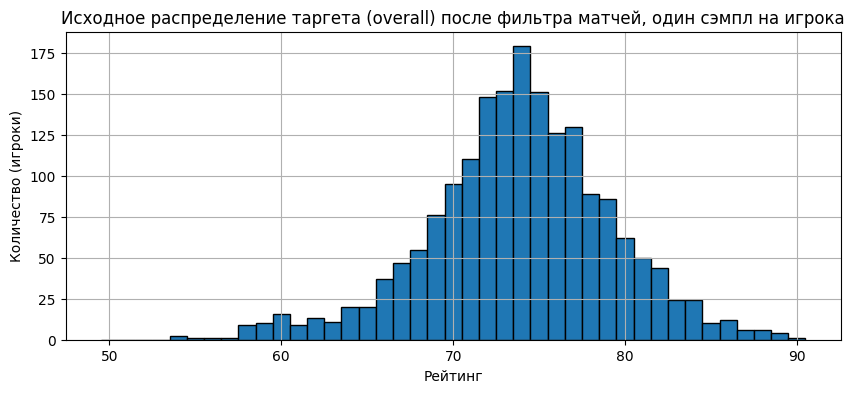

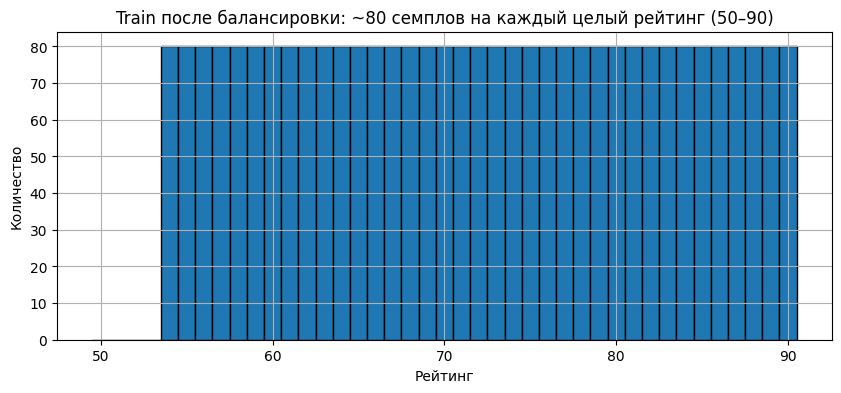

Epoch 1/200  train_loss=1.6954  eval_acc=0.2138
Epoch 10/200  train_loss=0.5431  eval_acc=0.3551
Epoch 20/200  train_loss=0.2818  eval_acc=0.3551
Epoch 30/200  train_loss=0.1699  eval_acc=0.3478
Epoch 40/200  train_loss=0.1058  eval_acc=0.3225
Epoch 50/200  train_loss=0.0742  eval_acc=0.3261
Epoch 60/200  train_loss=0.0585  eval_acc=0.3370
Epoch 70/200  train_loss=0.0465  eval_acc=0.3225
Epoch 80/200  train_loss=0.0288  eval_acc=0.3370
Epoch 90/200  train_loss=0.0291  eval_acc=0.3333
Epoch 100/200  train_loss=0.0245  eval_acc=0.3080
Epoch 110/200  train_loss=0.0224  eval_acc=0.3297
Epoch 120/200  train_loss=0.0154  eval_acc=0.3442
Epoch 130/200  train_loss=0.0155  eval_acc=0.3188
Epoch 140/200  train_loss=0.0184  eval_acc=0.3442
Epoch 150/200  train_loss=0.0182  eval_acc=0.3587
Epoch 160/200  train_loss=0.0139  eval_acc=0.3406
Epoch 170/200  train_loss=0.0124  eval_acc=0.3442
Epoch 180/200  train_loss=0.0160  eval_acc=0.3587
Epoch 190/200  train_loss=0.0130  eval_acc=0.3261
Epoch 200/2

,model,type,n_train_balanced,n_eval,acc_nn_best,acc_adaboost,acc_xgboost
0,RisingBaller_128_learned,transformer,2960,276,0.384058,0.275362,0.365942
1,RisingBaller_128_sinusoidal,transformer,2960,276,0.369565,0.221014,0.322464
2,RisingBaller_64_learned,transformer,2960,276,0.358696,0.253623,0.351449
3,RisingBaller_64_sinusoidal,transformer,2960,276,0.347826,0.282609,0.376812
4,gMLP_main_eq_128_te_f,gmlp,2960,276,0.340580,0.275362,0.307971
5,gMLP_main_eq_64_te_f,gmlp,2960,276,0.318841,0.293478,0.355072


In [5]:
# Классификация бинов (8 классов). Train балансируется по каждому целому overall 50..90 (~TARGET_SAMPLES_PER_RATING штук).
# Eval без балансировки. Три головы: нейросеть, AdaBoost, XGBoost; метрика — accuracy.

import json
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import xgboost as xgb
import joblib

from models.heads import ClassificationHead
from training.rating_trainer import RatingBinHeadTrainer

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

RATING_LO, RATING_HI = 50, 90
NUM_CLASSES = 8  # (overall_floor - 50) // 5, clamp 0..7 → последний бин 85–90
# Целевое число строк train на каждый целый рейтинг (50, 51, …, 90) после over/undersampling
TARGET_SAMPLES_PER_RATING = 80


def overall_to_bin(overalls: np.ndarray) -> np.ndarray:
    ov = np.floor(np.asarray(overalls, dtype=np.float64)).astype(int)
    return np.clip((ov - 50) // 5, 0, NUM_CLASSES - 1).astype(np.int64)


BIN_LABELS = [f"{50 + 5 * i}–{min(54 + 5 * i, 90)}" for i in range(NUM_CLASSES)]


def balance_train_by_integer_rating(
    train_idx: np.ndarray,
    overalls: np.ndarray,
    rng: np.random.Generator,
    target_per_rating: int,
    rating_lo: int,
    rating_hi: int,
) -> np.ndarray:
    """Для каждого целого рейтинга в [rating_lo, rating_hi] — примерно target_per_rating семплов (over/under)."""
    ov_int = np.floor(np.asarray(overalls, dtype=np.float64)).astype(int)
    out: list[int] = []
    for r in range(rating_lo, rating_hi + 1):
        idx_r = train_idx[ov_int[train_idx] == r]
        if len(idx_r) == 0:
            continue
        if len(idx_r) < target_per_rating:
            extra = rng.choice(idx_r, size=target_per_rating - len(idx_r), replace=True)
            out.extend(idx_r.tolist())
            out.extend(extra.tolist())
        elif len(idx_r) > target_per_rating:
            sub = rng.choice(idx_r, size=target_per_rating, replace=False)
            out.extend(sub.tolist())
        else:
            out.extend(idx_r.tolist())
    rng.shuffle(out)
    return np.array(out, dtype=np.int64)


split_cache = None
results = []
example = None
rng = np.random.default_rng(42)

for ckpt_dir in CKPT_DIRS:
    model_type = infer_model_type(ckpt_dir)
    print("\n===", ckpt_dir.name, "(type:", model_type, ")===")

    embeddings, overalls, player_names = build_embeddings_for_ckpt(ckpt_dir, model_type)

    valid_mask = (overalls >= RATING_LO) & (overalls <= RATING_HI)
    embeddings = embeddings[valid_mask]
    overalls = overalls[valid_mask]
    player_names = [player_names[i] for i in range(len(player_names)) if valid_mask[i]]

    class_ids = overall_to_bin(overalls)
    n = len(overalls)
    if n == 0:
        print("Нет сэмплов в диапазоне рейтинга, пропуск")
        continue

    if split_cache is None:
        plt.figure()
        plt.hist(overalls, bins=np.arange(RATING_LO - 0.5, RATING_HI + 1.5, 1.0), edgecolor="black")
        plt.title("Исходное распределение таргета (overall, следующий год) после фильтра матчей")
        plt.xlabel("Рейтинг")
        plt.ylabel("Количество (игрок–сезон)")
        plt.show()

        idx_all = np.arange(n)
        try:
            tr_raw, ev = train_test_split(
                idx_all, test_size=0.15, stratify=class_ids, random_state=42
            )
        except ValueError:
            tr_raw, ev = train_test_split(idx_all, test_size=0.15, random_state=42)

        tr_bal = balance_train_by_integer_rating(
            tr_raw, overalls, rng, TARGET_SAMPLES_PER_RATING, RATING_LO, RATING_HI
        )

        plt.figure()
        plt.hist(overalls[tr_bal], bins=np.arange(RATING_LO - 0.5, RATING_HI + 1.5, 1.0), edgecolor="black")
        plt.title(
            f"Train после балансировки: ~{TARGET_SAMPLES_PER_RATING} семплов на каждый целый рейтинг ({RATING_LO}–{RATING_HI})"
        )
        plt.xlabel("Рейтинг")
        plt.ylabel("Количество")
        plt.show()

        bin_cfg = {
            "rating_lo": RATING_LO,
            "rating_hi": RATING_HI,
            "num_classes": NUM_CLASSES,
            "bin_labels": BIN_LABELS,
            "target_samples_per_integer_rating": TARGET_SAMPLES_PER_RATING,
        }
        (OUTPUT_BASE_DIR / "bin_config.json").write_text(
            json.dumps(bin_cfg, ensure_ascii=False, indent=2), encoding="utf-8"
        )
        split_cache = {
            "train_idx_balanced": tr_bal,
            "eval_idx": ev,
            "class_ids": class_ids,
            "bin_cfg": bin_cfg,
        }

    tr_idx = split_cache["train_idx_balanced"]
    ev_idx = split_cache["eval_idx"]
    y = split_cache["class_ids"]

    meta_train = pd.DataFrame({"overall": overalls[tr_idx], "class_id": y[tr_idx]})
    meta_eval = pd.DataFrame({"overall": overalls[ev_idx], "class_id": y[ev_idx]})
    train_ds = SofifaAggregatedDataset(embeddings[tr_idx], meta_train)
    eval_ds = SofifaAggregatedDataset(embeddings[ev_idx], meta_eval)

    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=0)
    eval_loader = DataLoader(eval_ds, batch_size=64, shuffle=False, num_workers=0)

    X_train = embeddings[tr_idx]
    y_train = y[tr_idx].astype(np.int64)
    X_eval = embeddings[ev_idx]
    y_eval = y[ev_idx].astype(np.int64)

    out_dir = OUTPUT_BASE_DIR / ckpt_dir.name
    out_dir.mkdir(parents=True, exist_ok=True)
    (out_dir / "bin_config.json").write_text(
        json.dumps(split_cache["bin_cfg"], ensure_ascii=False, indent=2), encoding="utf-8"
    )

    # 1) AdaBoost (классификация)
    model_adaboost = AdaBoostClassifier(
        n_estimators=100, learning_rate=0.5, random_state=42
    )
    model_adaboost.fit(X_train, y_train)
    acc_ada = float(accuracy_score(y_eval, model_adaboost.predict(X_eval)))
    joblib.dump(model_adaboost, out_dir / "adaboost.joblib")

    # 2) XGBoost (классификация)
    model_xgboost = xgb.XGBClassifier(
        n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42
    )
    model_xgboost.fit(X_train, y_train)
    acc_xgb = float(accuracy_score(y_eval, model_xgboost.predict(X_eval)))
    joblib.dump(model_xgboost, out_dir / "xgboost.joblib")

    # 3) Нейросеть
    embed_size = int(embeddings.shape[1])
    head = ClassificationHead(
        embed_size=embed_size,
        num_classes=NUM_CLASSES,
        hidden_dim=128,
        pool="per_sequence",
    ).to(device)

    trainer = RatingBinHeadTrainer(
        head=head,
        train_loader=train_loader,
        eval_loader=eval_loader,
        output_dir=str(out_dir),
        num_epochs=200,
        lr=1e-3,
        weight_decay=0.01,
        device=device,
        logging_steps=10,
        save_best=True,
    )
    best_acc_nn = float(trainer.train())

    results.append(
        {
            "model": ckpt_dir.name,
            "type": model_type,
            "n_train_balanced": len(tr_idx),
            "n_eval": len(ev_idx),
            "acc_nn_best": best_acc_nn,
            "acc_adaboost": acc_ada,
            "acc_xgboost": acc_xgb,
        }
    )

    if example is None:
        head.eval()
        preds_cls: list[int] = []
        with torch.no_grad():
            for j in ev_idx:
                emb = (
                    torch.from_numpy(embeddings[j].copy())
                    .float()
                    .unsqueeze(0)
                    .unsqueeze(1)
                    .to(device)
                )
                mask = torch.ones(1, 1, dtype=torch.long, device=device)
                logits = head(emb, mask)
                preds_cls.append(int(logits.argmax(dim=-1).cpu().item()))

        example = {
            "model": ckpt_dir.name,
            "игрок": [player_names[j] for j in ev_idx],
            "истинный_бин": [BIN_LABELS[int(y[j])] for j in ev_idx],
            "предсказание_нейросеть_бин": [BIN_LABELS[p] for p in preds_cls],
            "истинный_рейтинг": [int(np.floor(overalls[j])) for j in ev_idx],
        }

results_df = pd.DataFrame(results).sort_values(
    ["acc_nn_best", "acc_xgboost", "acc_adaboost"], ascending=False
)
results_df.to_csv(OUTPUT_BASE_DIR / "results.csv", index=False)
results_df

In [6]:
# Пример: только нейросеть — истинный и предсказанный бин (и целый рейтинг для контекста)

assert example is not None, "example is None: сначала запусти ячейку выше (results_df)"

table = pd.DataFrame(
    {
        "model": example["model"],
        "игрок": example["игрок"],
        "рейтинг_целый": example["истинный_рейтинг"],
        "истинный_бин": example["истинный_бин"],
        "предсказание_нейросеть_бин": example["предсказание_нейросеть_бин"],
    }
)
table

,model,игрок,рейтинг_целый,истинный_бин,предсказание_нейросеть_бин
0,RisingBaller_128_learned,Timm Klose,76,75–79,75–79
1,RisingBaller_128_learned,Craig Dawson,66,65–69,75–79
2,RisingBaller_128_learned,Alessandro Florenzi,79,75–79,75–79
3,RisingBaller_128_learned,Marcel Risse,75,75–79,75–79
4,RisingBaller_128_learned,Jerónimo Figueroa Cabrera,70,70–74,75–79
...,...,...,...,...,...
271,RisingBaller_128_learned,Mehdi Zeffane,68,65–69,70–74
272,RisingBaller_128_learned,David Omar Rodríguez Barrera,70,70–74,70–74
273,RisingBaller_128_learned,Leroy Sané,76,75–79,65–69
274,RisingBaller_128_learned,Marco Russ,75,75–79,70–74
